# BLS API exploration

Probe the BLS MCP tools. The MCP server must be running (`python mcp_server/server.py`).

In [1]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.append('../')

from lib.utils import print_json_vertical
from utils import bls_series_to_arrays, plot_bls_series, bls_point_to_date
from matplotlib import pyplot
from lib import config

from utils import (
    call_tool,
    list_mcp_tools,
    show_all_surveys,
    popular_series,
    fetch_series,
)

pyplot.style.use(config.glyfish_style)

## Available tools

In [2]:
await list_mcp_tools()

fred_category_children: List the child categories for a FRED category.
fred_category_series: List the series contained within a FRED category.
fred_series_info: Fetch metadata for a single FRED series.
fred_series_observations: Return observations for a series (limit defaults to 100).
fred_series_updates: Return recently updated FRED series.
list_releases: List the series that belong to a FRED release.
fred_release_series: List the series that belong to a FRED release.
tiingo_series_info: Fetch metadata for a Tiingo ticker (ETF, mutual fund, or stock), including its available date range.
tiingo_price_series: Return the end-of-day price series (OHLCV plus split/dividend-adjusted prices) for a Tiingo ticker. Provide start_date/end_date as YYYY-MM-DD for a range; omit for the latest day.
bls_series_data: Fetch observations for one or more BLS series IDs (up to 50). Optionally restrict to a start_year/end_year range and enable catalog metadata, net/percent-change calculations, annual avera

## All surveys

In [3]:
surveys = await show_all_surveys()

AP: Consumer Price Index - Average Price Data
BD: Business Employment Dynamics
BG: Collective Bargaining Agreements-State and Local Government
BP: Collective Bargaining Agreements-Private Sector
CA: Biennial Nonfatal Case and Demographic numbers and rates: selected characteristics
CB: Biennial Nonfatal Case and Demographic numbers and rates: selected characteristics
CC: Employer Costs for Employee Compensation
CD: Nonfatal cases involving days away from work: selected characteristics
CE: Employment, Hours, and Earnings from the Current Employment Statistics survey (National)
CF: Census of Fatal Occupational Injuries
CH: Nonfatal cases involving days away from work: selected characteristics (2003 - 2010)
CI: Employment Cost Index
CM: Employer Costs for Employee Compensation
CS: Nonfatal cases involving days away from work: selected characteristics (2011 forward)
CU: Consumer Price Index - All Urban Consumers
CW: Consumer Price Index - Urban Wage Earners and Clerical Workers
CX: Consumer

## Single survey metadata

In [4]:
result = await call_tool("bls_survey_info", {"survey_abbreviation": "TU"})

if result is not None and result.structuredContent is not None:
    print_json_vertical(result.structuredContent["result"])

{
  "message": [],
  "response_time": 9,
  "results": {
    "survey": [
      {
        "allows_net_change": "false",
        "allows_percent_change": "false",
        "has_annual_averages": "false",
        "survey_abbreviation": "TU",
        "survey_name": "American Time Use"
      }
    ]
  },
  "status": "REQUEST_SUCCEEDED"
}


## Popular series (overall, then for one survey)

In [5]:
print(await popular_series())

['CUUR0000SA0', 'LNS14000000', 'CES0000000001', 'CUUR0000SA0L1E', 'WPUFD49104', 'CUSR0000SA0', 'CES0500000003', 'WPUFD4', 'ISU00000000031004', 'ISU00000000031029', 'ISU00000000031006', 'ISU00000000031051', 'ISU00000000031022', 'ISU00000000031019', 'ISU00000000031039', 'ISU00000000031026', 'ISU00000000031013', 'ISU00000000031005', 'ISU00000000031017', 'ISU00000000031053', 'ISU00000000031048', 'ISU00000000031021', 'ISU00000000031027', 'ISU00000000031001', 'ISU00000000031018']


In [6]:
print(await popular_series("LA"))

['LASST060000000000003', 'LASST170000000000003', 'LASST040000000000003', 'LASST350000000000003', 'LASST440000000000003', 'LASST050000000000003', 'LASST240000000000003', 'LASST420000000000003', 'LASST110000000000003', 'LASST320000000000003', 'LASST480000000000006', 'LASST310000000000006', 'LASST110000000000005', 'LASST510000000000006', 'LASST360000000000003', 'LASST340000000000004', 'LASST180000000000006', 'LASST350000000000004', 'LASST540000000000005', 'LASST370000000000004', 'LASST120000000000005', 'LASST390000000000005', 'LASST410000000000005', 'LASST210000000000005', 'LASST120000000000006']


## Latest datapoint for a series

In [7]:
result = await call_tool("bls_series_latest", {"series_id": "LNS14000000"})

if result is not None and result.structuredContent is not None:
    print_json_vertical(result.structuredContent["result"])

{
  "message": [],
  "response_time": 101,
  "results": {
    "series": [
      {
        "catalog": null,
        "data": [
          {
            "aspects": [],
            "calculations": null,
            "footnotes": [
              {
                "code": null,
                "text": null
              }
            ],
            "latest": "true",
            "period": "M06",
            "period_name": "June",
            "value": "4.2",
            "year": "2026"
          }
        ],
        "series_id": "LNS14000000"
      }
    ]
  },
  "status": "REQUEST_SUCCEEDED"
}


## Series data with catalog + calculations

In [8]:
result = await call_tool(
    "bls_series_data",
    {
        "series_ids": ["LNS14000000"],
        "start_year": 2003,
        "end_year": 2023,
        "catalog": True,
        "calculations": True,
    },
)

if result is not None and result.structuredContent is not None:
    print_json_vertical(result.structuredContent["result"])
else:
    print("No result or structuredContent is None")

{
  "message": [
    "Year range has been reduced to the system-allowed limit of 20 years."
  ],
  "response_time": 132,
  "results": {
    "series": [
      {
        "catalog": {
          "commerce_industry": "All Industries",
          "cps_labor_force_status": "Unemployment rate",
          "demographic_age": "16 years and over",
          "demographic_education": "All educational levels",
          "demographic_ethnic_origin": "All Origins",
          "demographic_gender": "Both Sexes",
          "demographic_race": "All Races",
          "measure_data_type": "Percent or rate",
          "occupation": "All Occupations",
          "seasonality": "Seasonally Adjusted",
          "series_id": "LNS14000000",
          "series_title": "(Seas) Unemployment Rate",
          "survey_abbreviation": "LN",
          "survey_name": "Labor Force Statistics from the Current Population Survey"
        },
        "data": [
          {
            "aspects": [],
            "calculations": {
    

## Plot Series Data

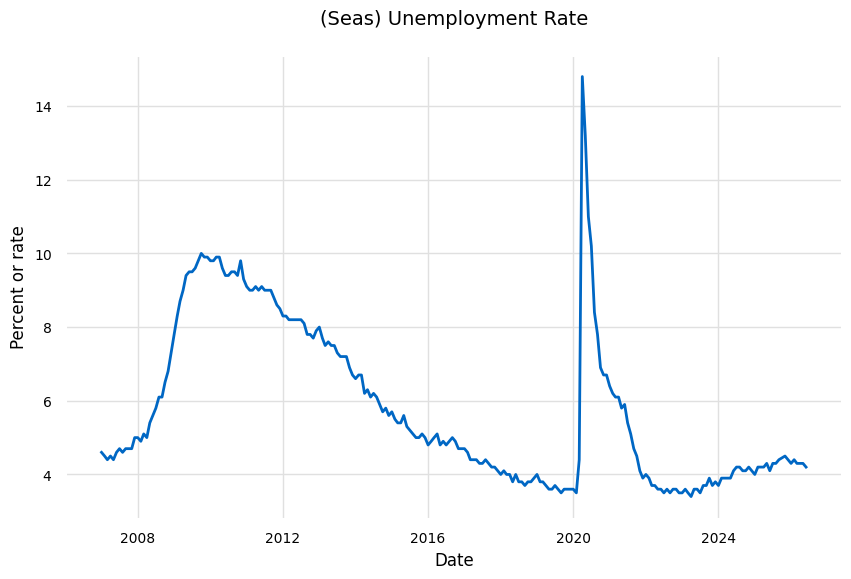

In [9]:
result = await call_tool("bls_series_data", {
    "series_ids": ["LNS14000000"], "start_year": 2007, "end_year": 2026, "catalog": True,
})

if result is not None and result.structuredContent is not None:
    series = result.structuredContent["result"]["results"]["series"][0]
    plot_bls_series(series)
else:
    print("No result or structuredContent is None")